✍️ 3.1 – Chargement et division du jeu de données

Chargez le fichier .csv à l’aide de pandas.
Séparez les données en caractéristiques (X) et étiquettes (y).
Divisez les données en trois sous-ensembles :
Entraînement : 70 %
Validation : 15 %
Test : 15 %
💡 Utilisez train_test_split de sklearn.model_selection avec l’option stratify=y pour garantir une répartition équilibrée des classes dans chaque ensemble.

In [1]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Charger le CSV (adapter le chemin si besoin)
df = pd.read_csv("features_apnea.csv")

print(df.head())

# Séparer X (caractéristiques) et y (étiquettes)
y = df["label"]
X = df.drop("label", axis = 1) # axis = 1 pour enlever une colonne

print(f"Forme X: {X.shape}, y: {y.shape}")

# Division des données en trois sous-ensembles, Entraînement 70 %, Validation 15 %,	Test 15 %
# stratify=y conserve la même proportion de classes (0/1) dans train et temp que dans y global (important si classes déséquilibrées)
# random_state = 42 graine aléatoire pour que le split soit reproductible (tu obtiens les mêmes indices à chaque exécution)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
# Split du temporaire en 50/50 → 15% val / 15% test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

     std_hr       sdsd       sdnn      rmssd  range_nni   pnni_50    pnni_20  \
0  3.865042  28.914892  51.350298  28.929623      210.0  9.090909  25.757576   
1  9.466601  63.461381  64.394408  63.718129      510.0  7.042254  36.619718   
2  7.228175  33.950025  77.897603  33.973029      250.0  9.589041  32.876712   
3  6.908339  23.532539  60.127799  23.533936      220.0  5.063291  22.784810   
4  4.157602  26.609214  44.067743  26.612388      220.0  5.405405  27.027027   

   nni_50  nni_20     min_hr  ...        s1       hfnu       lfnu  \
0       6      17  60.000000  ... -0.090104  27.714471  72.285529   
1       5      26  65.217391  ... -4.043881  38.583398  61.416602   
2       7      24  65.217391  ... -0.039899  35.607869  64.392131   
3       4      18  72.289157  ... -0.696874  10.951904  89.048096   
4       4      20  65.217391  ...  0.296199  13.441467  86.558533   

   lf_hf_ratio  total_power           lf           hf          vlf      perm  \
0     2.608223  2664.032

# MLP breast cancer

Le dataset **Breast Cancer Wisconsin** est un jeu de données médicales qui regroupe les mesures de 569 patientes atteintes de tumeurs du sein. Chaque tumeur est décrite par 30 caractéristiques numériques (par exemple le rayon moyen, la texture, la concavité). L’objectif est de prédire si la tumeur est maligne (cancéreuse) ou bénigne (non cancéreuse).

Cet ensemble de données constitue un excellent support pour se familiariser avec le **Perceptron Multicouche (MLP)**, puisqu'il s'agit d'un problème de classification binaire clair, fondé sur des données réelles et cliniquement pertinentes.

## Partie A: Conception, validation et évaluation d’un MLP

* Chargement & préparation des données (X, y)

Pourquoi ? On sépare les variables explicatives (features) de la cible (diagnostic bénin/malin).

In [ ]:
from sklearn.datasets import load_breast_cancer  # permet de charger un dataset intégré à Scikit-learn
import pandas as pd
import numpy as np

bc_data = load_breast_cancer()
#X = np.array(bc_data.data)
X = pd.DataFrame(bc_data.data, columns=bc_data.feature_names)  # 30 features tabulaires
y = bc_data.target
#y = pd.Series(bc_data.target, name="label")                 # 0 = malin, 1 = bénin

### Découpage train / validation / test (70% / 15% / 15%) avec stratification

**Pourquoi ?**

* **Train** : sert à apprendre les poids du réseau.
* **Validation** : sert à ajuster les **hyperparamètres** et vérifier si le modèle généralise.
* **Test** : sert uniquement à évaluer la performance finale.

**Stratify** maintient **l’équilibre des classes** dans chaque sous-ensemble

In [ ]:
from sklearn.model_selection import train_test_split # fonction qui permet de diviser les données en sous-ensembles

# split train vs temp (val+test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)

# split temp en val et test (50/50 -> 15% chacun)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

# random_state=42 -> fixe la graine aléatoire pour reproduire exactement la même séparation


### Créer et entraîner un MLP

Un **Perceptron Multicouche (MLP)** est un réseau de neurones artificiels qui apprend à reconnaître des motifs dans les données.

Dans notre exemple, il doit apprendre à prédire si une tumeur est **maligne** ou **bénigne** à partir de 30 caractéristiques numériques


In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

mlp_raw = MLPClassifier(hidden_layer_sizes=(50,), max_iter=500, random_state=42)
# hidden_layer_sizes=(50,) → une couche cachée de 50 neurones.
# max_iter=500 → nombre maximum d’itérations pour apprendre.

mlp_raw.fit(X_train, y_train) # lance l'entraînement.


### Évaluer le modèle

In [ ]:
y_pred_val_raw = mlp_raw.predict(X_val) # donne les prédictions du modèle (validation set)
y_pred_test_raw = mlp_raw.predict(X_test) # donne les prédictions du modèle (test set)

acc_val_raw = accuracy_score(y_val, y_pred_val_raw) # compare avec les vraies valeurs
acc_test_raw = accuracy_score(y_test, y_pred_test_raw) # compare avec les vraies valeurs


### Normalisation (StandardScaler) — fit uniquement sur train

Pourquoi ? Les MLP sont sensibles à l’échelle des features (meilleure convergence, poids stables).

Attention data leakage : on fit le scaler sur train puis on transform val/test.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train) # on calcule µ, σ sur train
X_val_s   = scaler.transform(X_val) # on applique µ, σ de train sur val
X_test_s  = scaler.transform(X_test) # on applique µ, σ de train sur test


### Créer et entraîner un MLP avec normalisation

In [ ]:
mlp_scaled = MLPClassifier(hidden_layer_sizes=(50,), max_iter=500, random_state=42)
mlp_scaled.fit(X_train_s, y_train)

### Évaluer le modèle avec normalisation

In [ ]:
y_pred_val_scaled = mlp_scaled.predict(X_val_s)
y_pred_test_scaled = mlp_scaled.predict(X_test_s)

acc_val_scaled = accuracy_score(y_val, y_pred_val_scaled)
acc_test_scaled = accuracy_score(y_test, y_pred_test_scaled)

### Comparer les résultats

In [ ]:
print("=== Résultats MLP ===")
print(f"Sans normalisation : Validation = {acc_val_raw:.3f}, Test = {acc_test_raw:.3f}")
print(f"Avec normalisation : Validation = {acc_val_scaled:.3f}, Test = {acc_test_scaled:.3f}")

In [ ]:
import matplotlib.pyplot as plt

loss_raw = mlp_raw.loss_curve_
loss_scaled = mlp_scaled.loss_curve_

# Tracer la courbe de perte
plt.plot(loss_raw, label="Sans normalisation")
plt.plot(loss_scaled, label="Avec normalisation")
plt.title("Convergence du MLP (Loss vs itérations)")
plt.xlabel("Itérations")
plt.ylabel("Loss (erreur)")
plt.legend()
plt.grid(True)
plt.show()

### Modèle MLP et grille d’hyperparamètres “manuelle”

Pourquoi ? Comme au labo, on teste quelques combinaisons (taille des couches, activation, alpha L2) et on choisit selon l’accuracy sur validation.

In [ ]:
from sklearn.metrics import confusion_matrix, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

configs = [
    {"hidden_layer_sizes": (10,),      "activation": "relu", "alpha": 1e-2},
    {"hidden_layer_sizes": (20,),      "activation": "relu", "alpha": 1e-2},
    {"hidden_layer_sizes": (20, 10),   "activation": "relu", "alpha": 1e-3},
    {"hidden_layer_sizes": (20, 10),   "activation": "tanh", "alpha": 1e-3},
    {"hidden_layer_sizes": (50, 20),   "activation": "relu", "alpha": 1e-4},
    {"hidden_layer_sizes": (64, 32),  "activation": "relu", "alpha": 1e-3},
    {"hidden_layer_sizes": (64,),  "activation": "relu", "alpha": 1e-3},
]

results = []
for i, cfg in enumerate(configs, 1):
    print("="*50)
    print(f"Configuration {i}: {cfg}")
    mlp = MLPClassifier(
        hidden_layer_sizes=cfg["hidden_layer_sizes"],
        activation=cfg["activation"],
        alpha=cfg["alpha"],
        solver="adam",
        max_iter=500,
        random_state=42
    )
    mlp.fit(X_train_s, y_train)
    print("Nombre d'itérations effectuées :", mlp.n_iter_)
    
    # Accuraty
    acc_train = accuracy_score(y_train, mlp.predict(X_train_s))
    acc_val   = accuracy_score(y_val,   mlp.predict(X_val_s))
    acc_test = accuracy_score(y_test, mlp.predict(X_test_s))

    # Matrice de confusion
    cm_train = confusion_matrix(y_train, mlp.predict(X_train_s))
    cm_val   = confusion_matrix(y_val, mlp.predict(X_val_s))
    cm_test  = confusion_matrix(y_test, mlp.predict(X_test_s))

    print(f"Accuracy Train: {acc_train:.3f}")
    print(f"Accuracy Val  : {acc_val:.3f}")
    print(f"Accuracy Test : {acc_test:.3f}")
    print("\nConfusion Matrix (Train):\n", cm_train)
    print("Confusion Matrix (Val):\n", cm_val)
    print("Confusion Matrix (Test):\n", cm_test)

    # AUC et ROC sur validation (facultatif)
    y_proba_val = mlp.predict_proba(X_val_s)[:,1]
    auc_val = roc_auc_score(y_val, y_proba_val)
    print(f"AUC (validation): {auc_val:.3f}")

    RocCurveDisplay.from_predictions(y_val, y_proba_val)
    plt.title(f"ROC Curve - Config {i}")
    plt.show()

    # Sauvegarder les résultats
    results.append({
        "config": cfg,
        "acc_train": acc_train,
        "acc_val": acc_val,
        "acc_test": acc_test,
        "auc_val": auc_val,
        "cm_train": cm_train,
        "cm_val": cm_val,
        "cm_test": cm_test
    })



In [ ]:
# Sélection de la meilleure config selon l'accuracy validation

best_cfg = None
best_score = -1

for r in results:
    if r["acc_val"] > best_score:   # on compare sur la validation
        best_score = r["acc_val"]
        best_cfg = r["config"]

print("Meilleure configuration :", best_cfg)
print("Score validation :", best_score)


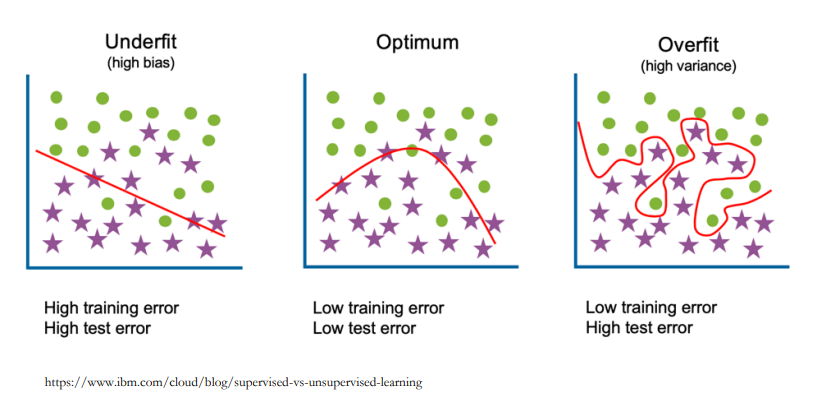

## Courbes d’apprentissage

Dans cet exercice, nous allons analyser l’évolution de l’entraînement d’un **MLP** en suivant ses **courbes de perte** (loss) sur l’ensemble d’entraînement et de validation, afin de mettre en évidence le **sous-ajustement** (underfitting) et le **sur-ajustement** (overfitting).

On Choisit une configuration **MLP** qui est assez complexe pour voir un surapprentissage (par ex. `hidden_layer_sizes=(100,20,10), activation="relu", alpha=1e-5`)

On utilise l'astuce suivante pour entraîner époque par époque:
* `warm_start=True` (le modèle continue l’entraînement au lieu de repartir à zéro),
* `max_iter=1` dans une boucle `for`

Après chaque époque, on enregistre:
* la **perte (loss)** sur l'ensemble **train**,
* la **perte (loss)** sur l'ensemble **validation**,

In [ ]:
from sklearn.metrics import log_loss

epochs = 800
train_losses, val_losses = [], []
train_accs, val_accs = [], []

mlp = MLPClassifier(
    hidden_layer_sizes=(100,10),
    activation="relu",
    alpha=0.00001,
    solver="adam",
    batch_size=64,
    learning_rate_init=1e-4,
    warm_start=True,
    max_iter=1,
    random_state=42
)

for epoch in range(epochs):
    mlp.fit(X_train_s, y_train)

    # Probabilités pour calculer la perte (log-loss)
    y_train_proba = mlp.predict_proba(X_train_s)
    y_val_proba   = mlp.predict_proba(X_val_s)

    train_loss = log_loss(y_train, y_train_proba)
    val_loss   = log_loss(y_val, y_val_proba)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Accuracy pour train et val
    y_train_pred = mlp.predict(X_train_s)
    y_val_pred   = mlp.predict(X_val_s)

    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc   = accuracy_score(y_val, y_val_pred)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

# Affichage
import matplotlib.pyplot as plt

# -----------------------
# Affichage
# -----------------------
plt.figure(figsize=(12,5))

# 1) Courbe des pertes
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Val loss")
plt.xlabel("Époques")
plt.ylabel("Perte (log-loss)")
plt.title("Courbes de perte (Loss)")
plt.legend()

# 2) Courbe des accuracies
plt.subplot(1,2,2)
plt.plot(train_accs, label="Train accuracy")
plt.plot(val_accs, label="Val accuracy")
plt.xlabel("Époques")
plt.ylabel("Accuracy")
plt.title("Courbes d’accuracy")
plt.legend()

plt.tight_layout()
plt.show()


### Courbe d'apprentissage sans normalisation du jeu de données

In [ ]:
epochs = 500
train_losses, val_losses = [], []
train_accs, val_accs = [], []

mlp = MLPClassifier(
    hidden_layer_sizes=(100,20),
    activation="relu",
    alpha=0.001,
    solver="adam",
    batch_size=128,
    learning_rate_init=1e-3,
    warm_start=True,
    max_iter=1,
    random_state=42
)

for epoch in range(epochs):
    mlp.fit(X_train, y_train)

    # Probabilités pour calculer la perte (log-loss)
    y_train_proba = mlp.predict_proba(X_train)
    y_val_proba   = mlp.predict_proba(X_val)

    train_loss = log_loss(y_train, y_train_proba)
    val_loss   = log_loss(y_val, y_val_proba)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Accuracy pour train et val
    y_train_pred = mlp.predict(X_train)
    y_val_pred   = mlp.predict(X_val)

    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc   = accuracy_score(y_val, y_val_pred)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

# Affichage
import matplotlib.pyplot as plt

# -----------------------
# Affichage
# -----------------------
plt.figure(figsize=(12,5))

# 1) Courbe des pertes
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Val loss")
plt.xlabel("Époques")
plt.ylabel("Perte (log-loss)")
plt.title("Courbes de perte (Loss)")
plt.legend()

# 2) Courbe des accuracies
plt.subplot(1,2,2)
plt.plot(train_accs, label="Train accuracy")
plt.plot(val_accs, label="Val accuracy")
plt.xlabel("Époques")
plt.ylabel("Accuracy")
plt.title("Courbes d’accuracy")
plt.legend()

plt.tight_layout()
plt.show()


### Focntion de lissage (EMA)

In [ ]:
# Fonction de lissage (EMA)
def smooth_curve(points, factor=0.9):
    smoothed = []
    for p in points:
        if smoothed:
            smoothed.append(smoothed[-1] * factor + p * (1 - factor))
        else:
            smoothed.append(p)
    return smoothed

# -----------------------
# Affichage avec smoothing
# -----------------------
plt.figure(figsize=(12,5))

# 1) Courbes de perte (loss)
plt.subplot(1,2,1)
plt.plot(train_losses, alpha=0.4, label="Train loss (raw)")
plt.plot(val_losses, alpha=0.4, label="Val loss (raw)")
plt.plot(smooth_curve(train_losses), label="Train loss (smoothed)")
plt.plot(smooth_curve(val_losses), label="Val loss (smoothed)")
plt.xlabel("Époques")
plt.ylabel("Perte (log-loss)")
plt.title("Courbes de perte (Loss) avec lissage")
plt.legend()

# 2) Courbes d’accuracy
plt.subplot(1,2,2)
plt.plot(train_accs, alpha=0.4, label="Train acc (raw)")
plt.plot(val_accs, alpha=0.4, label="Val acc (raw)")
plt.plot(smooth_curve(train_accs), label="Train acc (smoothed)")
plt.plot(smooth_curve(val_accs), label="Val acc (smoothed)")
plt.xlabel("Époques")
plt.ylabel("Accuracy")
plt.title("Courbes d’accuracy avec lissage")
plt.legend()

plt.tight_layout()
plt.show()